Using device: cpu


100.0%


Batch x shape: torch.Size([64, 3, 32, 32]), y shape: torch.Size([64])
x min: -1.000, max: 1.000
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

=== E1: Base MLP (no dropout, no batchnorm) ===
Epoch  1: Train Loss=1.6878, Train Acc=0.3958 | Val Loss=1.5413, Val Acc=0.4537
Epoch  2: Train Loss=1.4711, Train Acc=0.4795 | Val Loss=1.4979, Val Acc=0.4733
Epoch  3: Train Loss=1.3596, Train Acc=0.5190 | Val Loss=1.4145, Val Acc=0.5041
Epoch  4: Train Loss=1.2665, Train Acc=0.5531 | Val Loss=1.3778, Val Acc=0.5164
Epoch  5: Train Loss=1.1884, Train Acc=0.5752 | Val Loss=1.3774, Val Acc=0.5216
Epoch  6: Train Loss=1.1146, Train Acc=0.6051 | Val Loss=1.3973, Val Acc=0.5149
Epoch  7: Train Loss=1.0484, Train Acc=0.6272 | Val Loss=1.4199, Val Acc=0.5233
Epoch  8: Train Loss=0.9859, Train Acc=0.6498 | Val Loss=1.4405, Val Acc=0.5257
Epoch  9: Train Loss=0.9214, Train Acc=0.6712 | Val Loss=1.4617, Val Acc=0.5271
Epoch 10: Train Loss=0.8648, Train Acc=0.6925 | Val Loss=1.5062, Val Acc=0.5236
Epoch 11: Train

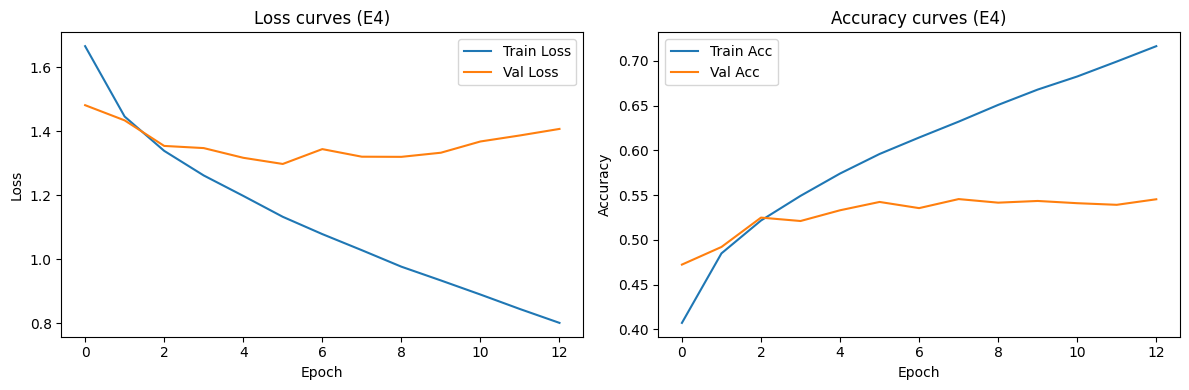

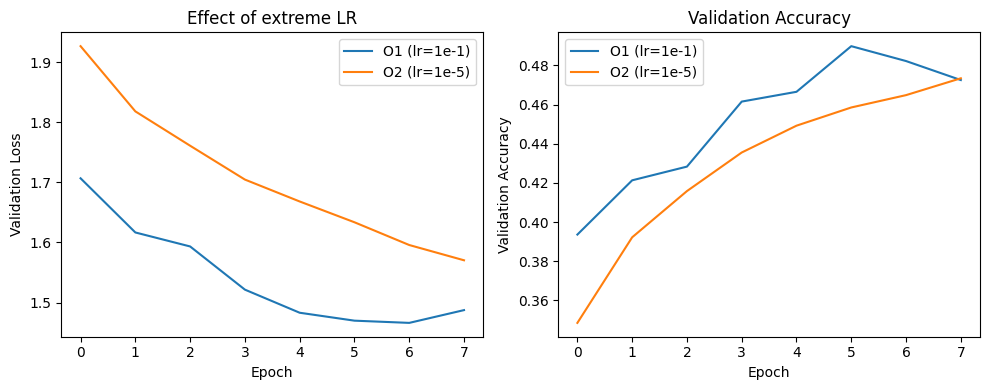


=== Final Test Evaluation ===
Test Loss: 1.3266, Test Accuracy: 0.5432


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from pathlib import Path
import random

# Фиксируем seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Трансформация: превращаем в тензор и нормализуем
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # для трёх каналов
])

# Загружаем train и test
train_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Размер val: 20% от train_full
val_size = int(0.2 * len(train_full))
train_size = len(train_full) - val_size

# Фиксированный сплит с помощью random_split
train_set, val_set = torch.utils.data.random_split(train_full, [train_size, val_size],
generator=torch.Generator().manual_seed(42))

# Создаем DataLoader'ы
batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# Проверка (sanity check)
x, y = next(iter(train_loader))
print(f'Batch x shape: {x.shape}, y shape: {y.shape}')
print(f'x min: {x.min():.3f}, max: {x.max():.3f}')
print(f'Classes: {y.unique().tolist()}')

class MLP(nn.Module):
    def __init__(self, input_size=3072, hidden_sizes=[256, 128], num_classes=10, dropout=None, use_batchnorm=False):
        super().__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout is not None:
                layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x shape: (batch, 1, 28, 28) -> flatten
        x = x.view(x.size(0), -1)
        return self.net(x)
    
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        _, pred = torch.max(outputs, 1)
        correct += (pred == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item() * x.size(0)
            _, pred = torch.max(outputs, 1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc

# Параметры по умолчанию (общие для всех экспериментов)
input_size = 3*32*32
num_classes = 10
hidden_sizes = [256, 128, 64]  # три скрытых слоя
activation = 'ReLU'
num_epochs = 15  # для E1, E2, E3 (кроме early stopping)
criterion = nn.CrossEntropyLoss()

# Для сохранения результатов
results = []

# Функция для выполнения одного эксперимента
def run_experiment(model, optimizer, num_epochs, experiment_id, **kwargs):
    # Сохраняем историю
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    patience_counter = 0
    early_stop_patience = kwargs.get('early_stop_patience', None)
    
    for epoch in range(1, num_epochs+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch:2d}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
        
        # Сохраняем лучшую модель по val_acc
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            patience_counter = 0
            if experiment_id == 'E4':
                torch.save(model.state_dict(), 'artifacts/best_model.pt')
        else:
            if early_stop_patience is not None:
                patience_counter += 1
                if patience_counter >= early_stop_patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
    # Возвращаем итоговые метрики и историю
    return best_val_acc, history

print("\n=== E1: Base MLP (no dropout, no batchnorm) ===")
model = MLP(input_size, hidden_sizes, num_classes, dropout=None, use_batchnorm=False).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
best_val_acc, history_e1 = run_experiment(model, optimizer, num_epochs, 'E1')
results.append({
    'experiment_id': 'E1',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'hidden=[256,128,64], ReLU, no dropout, no BN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history_e1['val_loss'])
})

print("\n=== E2: MLP with Dropout (p=0.3) ===")
model = MLP(input_size, hidden_sizes, num_classes, dropout=0.3, use_batchnorm=False).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
best_val_acc, history_e2 = run_experiment(model, optimizer, num_epochs, 'E2')
results.append({
    'experiment_id': 'E2',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'hidden=[256,128,64], ReLU, dropout=0.3',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history_e2['val_loss'])
})

print("\n=== E3: MLP with BatchNorm ===")
model = MLP(input_size, hidden_sizes, num_classes, dropout=None, use_batchnorm=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
best_val_acc, history_e3 = run_experiment(model, optimizer, num_epochs, 'E3')
results.append({
    'experiment_id': 'E3',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'hidden=[256,128,64], ReLU, BN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history_e3['val_loss'])
})

print("\n=== E4: Best of E2/E3 (BatchNorm) with EarlyStopping ===")
model = MLP(input_size, hidden_sizes, num_classes, dropout=None, use_batchnorm=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# Обучаем до 30 эпох с patience=5
best_val_acc, history_e4 = run_experiment(model, optimizer, num_epochs=30, experiment_id='E4', early_stop_patience=5)
# Узнаем реальное число обученных эпох (из длины истории)
epochs_trained_e4 = len(history_e4['val_loss'])
results.append({
    'experiment_id': 'E4',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'hidden=[256,128,64], ReLU, BN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': epochs_trained_e4,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history_e4['val_loss'])
})

print("\n=== O1: Adam, LR too high (1e-1) ===")
model = MLP(input_size, hidden_sizes, num_classes, dropout=None, use_batchnorm=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-1)
best_val_acc, history_o1 = run_experiment(model, optimizer, num_epochs=8, experiment_id='O1')
results.append({
    'experiment_id': 'O1',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'hidden=[256,128,64], ReLU, BN',
    'optimizer': 'Adam',
    'lr': 1e-1,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 8,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history_o1['val_loss'])
})

print("\n=== O2: Adam, LR too low (1e-5) ===")
model = MLP(input_size, hidden_sizes, num_classes, dropout=None, use_batchnorm=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)
best_val_acc, history_o2 = run_experiment(model, optimizer, num_epochs=8, experiment_id='O2')
results.append({
    'experiment_id': 'O2',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'hidden=[256,128,64], ReLU, BN',
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 8,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history_o2['val_loss'])
})

print("\n=== O3: SGD + momentum + weight decay ===")
model = MLP(input_size, hidden_sizes, num_classes, dropout=None, use_batchnorm=True).to(device)
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
best_val_acc, history_o3 = run_experiment(model, optimizer, num_epochs=15, experiment_id='O3')
results.append({
    'experiment_id': 'O3',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'hidden=[256,128,64], ReLU, BN',
    'optimizer': 'SGD',
    'lr': 1e-2,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': 15,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history_o3['val_loss'])
})

df = pd.DataFrame(results)
df.to_csv('artifacts/runs.csv', index=False)
print("Saved runs.csv")

best_config = {
    'experiment_id': 'E4',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model': 'MLP',
    'input_size': input_size,
    'hidden_sizes': hidden_sizes,
    'activation': 'ReLU',
    'use_batchnorm': True,
    'dropout': None,
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 0,
    'momentum': None,
    'epochs_trained': epochs_trained_e4,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history_e4['val_loss'])
}
with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_e4['train_loss'], label='Train Loss')
plt.plot(history_e4['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves (E4)')

plt.subplot(1,2,2)
plt.plot(history_e4['train_acc'], label='Train Acc')
plt.plot(history_e4['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy curves (E4)')
plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png')
plt.show()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_o1['val_loss'], label='O1 (lr=1e-1)')
plt.plot(history_o2['val_loss'], label='O2 (lr=1e-5)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.title('Effect of extreme LR')

plt.subplot(1,2,2)
plt.plot(history_o1['val_acc'], label='O1 (lr=1e-1)')
plt.plot(history_o2['val_acc'], label='O2 (lr=1e-5)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Validation Accuracy')
plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png')
plt.show()

# Загружаем лучшую модель (она уже сохранена из E4)
model_best = MLP(input_size, hidden_sizes, num_classes, dropout=None, use_batchnorm=True).to(device)
model_best.load_state_dict(torch.load('artifacts/best_model.pt'))
test_loss, test_acc = evaluate(model_best, test_loader, criterion)
print(f"\n=== Final Test Evaluation ===")
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Добавим эту информацию в отчёт (но можно и в отдельный файл)
# Сохраним в CSV или просто выведем.